# Anomaly Detection on Constitutional Profiles
Which countries have constitutions that are structurally unusual — outliers in the 14-dimensional constitutional space?  
We run **Isolation Forest** and **Local Outlier Factor (LOF)** on the latest constitutional profile for each country, then check whether structural anomalies overlap with the backsliding gap.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [2]:
SCORES_PATH = 'ccpc_axis_scores_llm.csv'
GAP_PATH    = 'backsliding_gap_kfold.csv'

FEATURES = [
    'ccpc_civil_liberties',
    'ccpc_socioeconomic_rights',
    'ccpc_political_competition',
    'ccpc_legislative_autonomy',
    'ccpc_executive_constraints',
    'ccpc_judicial_independence',
    'ccpc_rule_of_law_due_process',
    'ccpc_institutional_accountability',
    'ccpc_emergency_powers_constraints',
    'ccpc_civilian_control_of_security',
    'ccpc_amendment_rigidity',
    'ccpc_federalism_decentralization',
    'ccpc_transparency_information_access',
    'ccpc_equality_gender_minority_indigenous',
]

LABELS = {
    'ccpc_civil_liberties':                     'Civil liberties',
    'ccpc_socioeconomic_rights':                'Socioeconomic rights',
    'ccpc_political_competition':               'Political competition',
    'ccpc_legislative_autonomy':                'Legislative autonomy',
    'ccpc_executive_constraints':               'Executive constraints',
    'ccpc_judicial_independence':               'Judicial independence',
    'ccpc_rule_of_law_due_process':             'Rule of law / due process',
    'ccpc_institutional_accountability':        'Institutional accountability',
    'ccpc_emergency_powers_constraints':        'Emergency powers constraints',
    'ccpc_civilian_control_of_security':        'Civilian control of security',
    'ccpc_amendment_rigidity':                  'Amendment rigidity',
    'ccpc_federalism_decentralization':         'Federalism / decentralization',
    'ccpc_transparency_information_access':     'Transparency / info access',
    'ccpc_equality_gender_minority_indigenous': 'Equality (gender/minority/indigenous)',
}

## 1. Load & collapse to one profile per country
Constitutional scores are time-invariant within a constitutional period. We take the **latest constitution** per country (highest `systyear`) to get one row per country.

In [3]:
ccpc = pd.read_csv(SCORES_PATH)
ccpc['cowcode'] = pd.to_numeric(ccpc['cowcode'], errors='coerce')
ccpc['year']    = pd.to_numeric(ccpc['year'],    errors='coerce')
ccpc['systyear']= pd.to_numeric(ccpc['systyear'],errors='coerce')

# Latest year row per country (captures most recent constitutional profile)
latest = ccpc.sort_values('year').groupby('cowcode').last().reset_index()

# Drop rows where all features are missing
latest = latest.dropna(subset=FEATURES, how='all').copy()

print(f'Countries: {len(latest)}')
print(f'Features with any missing: {latest[FEATURES].isnull().any().sum()}')
print(f'Missing cells total: {latest[FEATURES].isnull().sum().sum()}')

Countries: 201
Features with any missing: 0
Missing cells total: 0


## 2. Impute & scale
Median imputation for missing cells (sparse missingness), then StandardScaler so no dimension dominates.

In [4]:
X_raw = latest[FEATURES].copy()

# Median imputation
for col in FEATURES:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Shape:', X.shape)
print('Any NaN after imputation:', np.isnan(X).any())

Shape: (201, 14)
Any NaN after imputation: False


## 3. Isolation Forest
Contamination = 10% means the model flags the most extreme ~10% of countries as anomalies.
The `anomaly_score` is the raw decision function — more negative = more anomalous.

In [5]:
iso = IsolationForest(contamination=0.10, random_state=42, n_estimators=300)
iso.fit(X)

latest['iso_label'] = iso.predict(X)           # -1 = anomaly, +1 = normal
latest['iso_score'] = iso.decision_function(X) # lower = more anomalous

n_anom = (latest['iso_label'] == -1).sum()
print(f'Isolation Forest flags {n_anom} countries as anomalous ({n_anom/len(latest)*100:.1f}%)')

Isolation Forest flags 20 countries as anomalous (10.0%)


## 4. Local Outlier Factor
LOF measures local density: a country is anomalous if it is much less dense than its constitutional neighbors.

In [6]:
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.10)
lof_labels = lof.fit_predict(X)       # -1 = anomaly, +1 = normal
lof_scores = -lof.negative_outlier_factor_  # higher = more anomalous

latest['lof_label'] = lof_labels
latest['lof_score'] = lof_scores

# Agreement between the two methods
both = ((latest['iso_label'] == -1) & (latest['lof_label'] == -1)).sum()
print(f'LOF flags {(latest["lof_label"]==-1).sum()} anomalies')
print(f'Both methods agree on {both} anomalous countries')

LOF flags 20 anomalies
Both methods agree on 10 anomalous countries


## 5. PCA — visualise the constitutional space
Two principal components for plotting. Color = Isolation Forest anomaly score (blue = more anomalous).

In [7]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
latest['pc1'] = coords[:, 0]
latest['pc2'] = coords[:, 1]

var1, var2 = pca.explained_variance_ratio_ * 100
print(f'PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  Total: {var1+var2:.1f}%')

PC1: 43.9%  |  PC2: 11.6%  |  Total: 55.5%


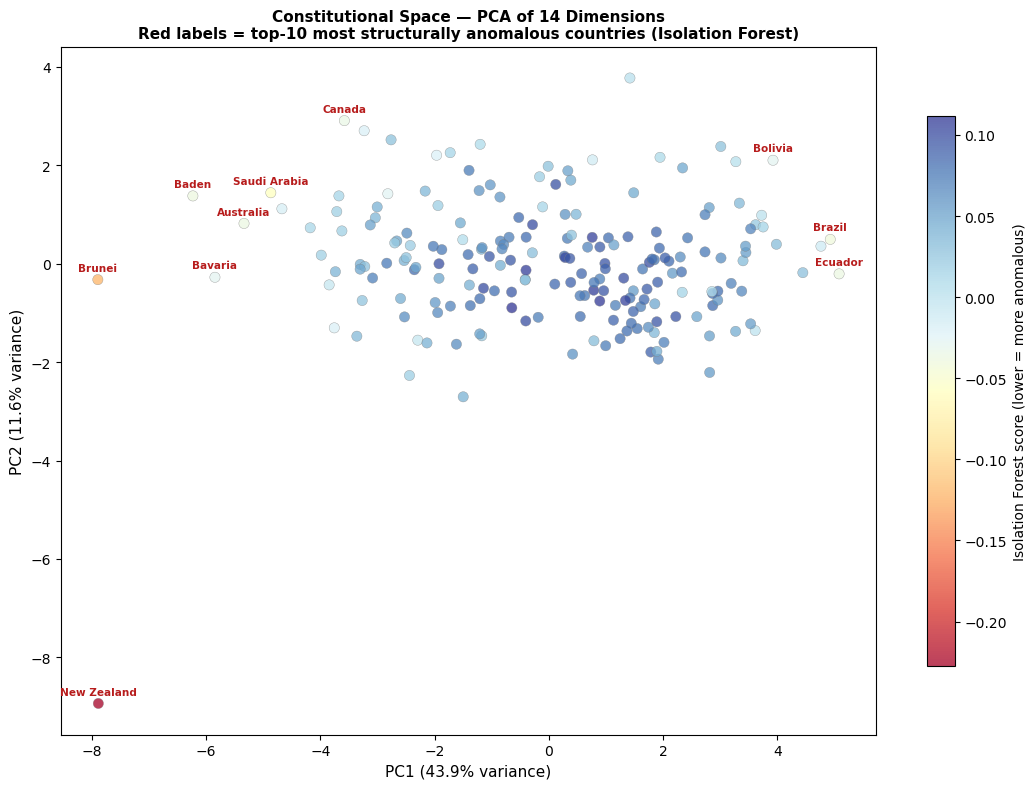

In [8]:
fig, ax = plt.subplots(figsize=(11, 8))

# All countries: colored by anomaly score
sc = ax.scatter(
    latest['pc1'], latest['pc2'],
    c=latest['iso_score'], cmap='RdYlBu',
    s=55, alpha=0.75, linewidths=0.3, edgecolors='grey',
    zorder=2
)
plt.colorbar(sc, ax=ax, label='Isolation Forest score (lower = more anomalous)', shrink=0.8)

# Label the top-10 most anomalous by Isolation Forest
top_anom = latest.nsmallest(10, 'iso_score')
for _, row in top_anom.iterrows():
    ax.annotate(
        row['country'], (row['pc1'], row['pc2']),
        fontsize=7.5, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        color='#b71c1c', fontweight='bold'
    )

ax.set_xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=11)
ax.set_title(
    'Constitutional Space — PCA of 14 Dimensions\n'
    'Red labels = top-10 most structurally anomalous countries (Isolation Forest)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 6. Which countries are flagged by both methods?

In [9]:
agreed = latest[(latest['iso_label'] == -1) & (latest['lof_label'] == -1)].copy()
agreed = agreed.sort_values('iso_score')[['country', 'systyear', 'iso_score', 'lof_score']].reset_index(drop=True)

pd.set_option('display.float_format', '{:.3f}'.format)
print(f'Countries flagged as anomalous by BOTH Isolation Forest and LOF ({len(agreed)} total):\n')
print(agreed.to_string(index=False))

Countries flagged as anomalous by BOTH Isolation Forest and LOF (10 total):

                            country  systyear  iso_score  lof_score
                        New Zealand  1852.000     -0.227      2.970
                             Brunei  1959.000     -0.121      1.409
                       Saudi Arabia  1992.000     -0.057      1.190
                             Canada  1867.000     -0.035      1.307
                     Great Colombia  1821.000     -0.027      1.294
                            Austria  1945.000     -0.021      1.278
Federal Republic of Central America  1835.000     -0.021      1.193
                              Tonga  1875.000     -0.020      1.234
                            Liberia  1986.000     -0.014      1.345
                      Guinea-Bissau  1984.000     -0.007      1.211


## 7. What makes anomalous countries unusual?
For the top-10 most anomalous (by Isolation Forest), compare their dimension scores to the global median.

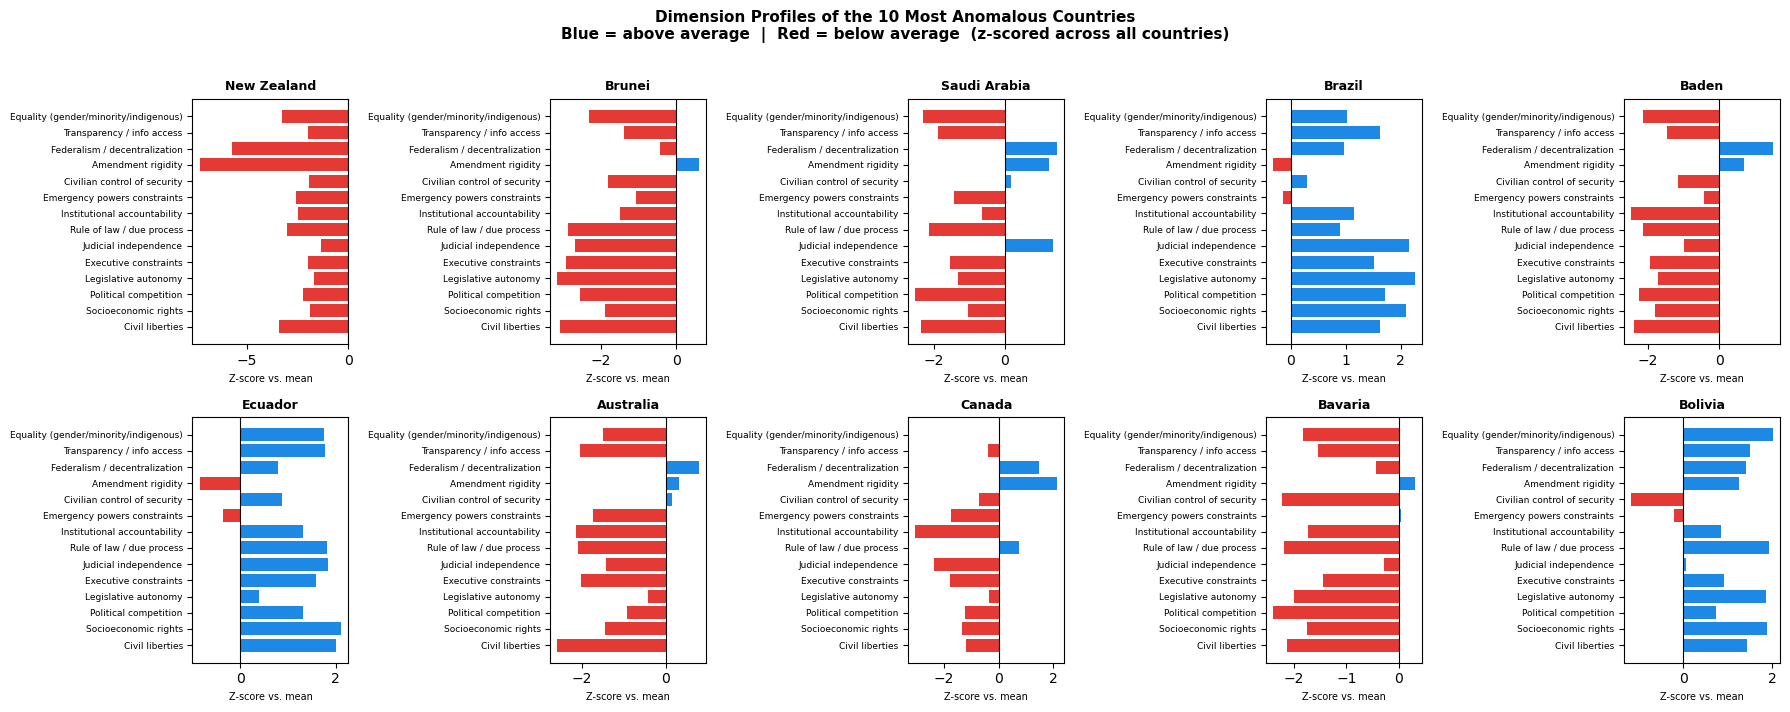

In [10]:
top10 = latest.nsmallest(10, 'iso_score').copy()
global_median = X_raw[FEATURES].median()

# Z-score deviation of each anomalous country from global median
medians_scaled = scaler.transform(global_median.values.reshape(1, -1))[0]

short_labels = [LABELS[f].replace(' / ', '/').replace(' (gender/minority/indigenous)', '\n(gender/min/ind)') for f in FEATURES]

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=False)
axes = axes.flatten()

for i, (_, row) in enumerate(top10.iterrows()):
    ax = axes[i]
    vals = scaler.transform(row[FEATURES].values.reshape(1, -1))[0]
    deviations = vals  # already z-scored; 0 = mean country
    colors = ['#e53935' if d < 0 else '#1e88e5' for d in deviations]
    ax.barh(range(len(FEATURES)), deviations, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(range(len(FEATURES)))
    ax.set_yticklabels([LABELS[f] for f in FEATURES], fontsize=6.5)
    ax.set_title(row['country'], fontsize=9, fontweight='bold')
    ax.set_xlabel('Z-score vs. mean', fontsize=7)

plt.suptitle(
    'Dimension Profiles of the 10 Most Anomalous Countries\n'
    'Blue = above average  |  Red = below average  (z-scored across all countries)',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 8. Do constitutionally anomalous countries backslide more?
Cross-reference anomaly flag with the backsliding gap from Step 3 (2016–2023 average).

In [11]:
gap = pd.read_csv(GAP_PATH)

# Average gap per country across 2016–2023
gap_avg = gap.groupby('COWcode')['residual'].mean().reset_index()
gap_avg.columns = ['cowcode', 'gap_avg']

merged = latest.merge(gap_avg, on='cowcode', how='inner')
print(f'Matched {len(merged)} countries with gap data')

Matched 164 countries with gap data


In [12]:
anom_gap   = merged.loc[merged['iso_label'] == -1, 'gap_avg']
normal_gap = merged.loc[merged['iso_label'] == 1,  'gap_avg']

print(f'Anomalous countries   — mean gap: {anom_gap.mean():.3f}  (n={len(anom_gap)})')
print(f'Non-anomalous countries — mean gap: {normal_gap.mean():.3f}  (n={len(normal_gap)})')

from scipy import stats
t, p = stats.ttest_ind(anom_gap, normal_gap)
print(f'\nWelch t-test: t = {t:.2f}, p = {p:.3f}')
print('Interpretation: ' + ('Anomalous countries have significantly different gap' if p < 0.05 else 'No significant difference in gap'))

Anomalous countries   — mean gap: 0.263  (n=11)
Non-anomalous countries — mean gap: 0.069  (n=153)

Welch t-test: t = 2.54, p = 0.012
Interpretation: Anomalous countries have significantly different gap


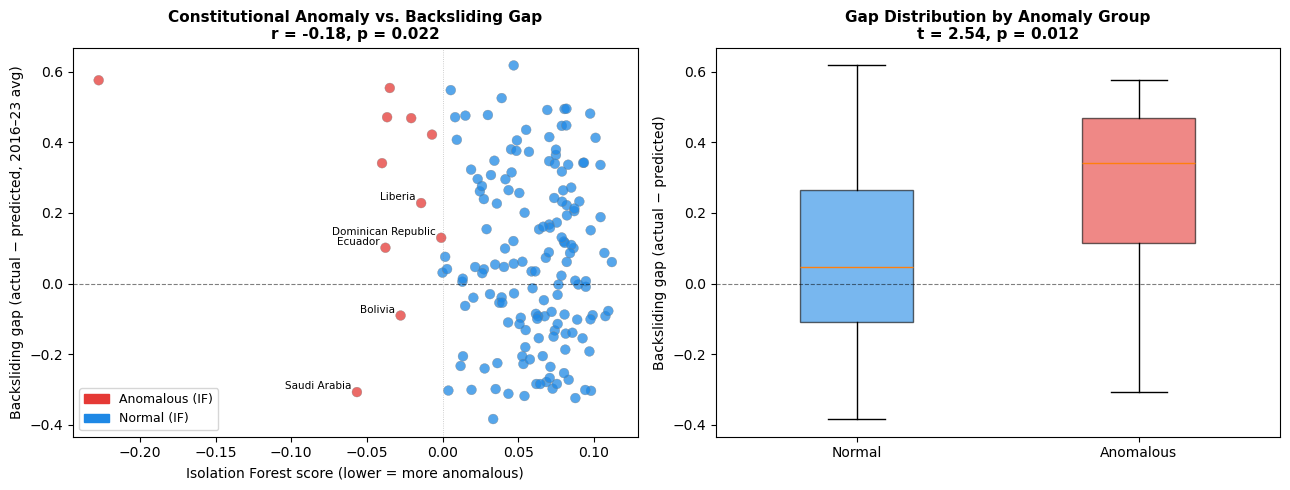

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: scatter of iso_score vs. gap ---
ax = axes[0]
sc = ax.scatter(
    merged['iso_score'], merged['gap_avg'],
    c=merged['iso_label'].map({-1: '#e53935', 1: '#1e88e5'}),
    s=50, alpha=0.75, linewidths=0.3, edgecolors='grey'
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='grey',  linewidth=0.6, linestyle=':',  alpha=0.5)

# Label the worst backsliders among anomalies
highlight = merged[merged['iso_label'] == -1].nsmallest(5, 'gap_avg')
for _, row in highlight.iterrows():
    ax.annotate(row['country'], (row['iso_score'], row['gap_avg']),
                fontsize=7.5, ha='right', xytext=(-4, 2), textcoords='offset points')

from scipy import stats as sp
r, pv = sp.pearsonr(merged['iso_score'], merged['gap_avg'])

legend_handles = [
    mpatches.Patch(color='#e53935', label='Anomalous (IF)'),
    mpatches.Patch(color='#1e88e5', label='Normal (IF)'),
]
ax.legend(handles=legend_handles, fontsize=9)
ax.set_xlabel('Isolation Forest score (lower = more anomalous)', fontsize=10)
ax.set_ylabel('Backsliding gap (actual − predicted, 2016–23 avg)', fontsize=10)
ax.set_title(f'Constitutional Anomaly vs. Backsliding Gap\nr = {r:.2f}, p = {pv:.3f}', fontsize=11, fontweight='bold')

# --- Right: boxplot by anomaly group ---
ax2 = axes[1]
groups = [normal_gap.values, anom_gap.values]
bp = ax2.boxplot(groups, labels=['Normal', 'Anomalous'], patch_artist=True, widths=0.4)
colors_box = ['#1e88e5', '#e53935']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_ylabel('Backsliding gap (actual − predicted)', fontsize=10)
ax2.set_title(f'Gap Distribution by Anomaly Group\nt = {t:.2f}, p = {p:.3f}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Summary table — anomalous countries & their backsliding gap

In [14]:
summary = (
    merged[merged['iso_label'] == -1]
    [['country', 'systyear', 'iso_score', 'lof_score', 'lof_label', 'gap_avg']]
    .sort_values('gap_avg')
    .reset_index(drop=True)
)
summary['both_flagged'] = (summary['lof_label'] == -1).map({True: 'Yes', False: 'No'})
summary = summary.drop(columns='lof_label')
summary.columns = ['Country', 'Constitution year', 'IF score', 'LOF score', 'Gap (avg 2016-23)', 'Both flagged']

pd.set_option('display.max_rows', 30)
print('Anomalous countries (Isolation Forest), sorted by backsliding gap:\n')
print(summary.to_string(index=False))

Anomalous countries (Isolation Forest), sorted by backsliding gap:

           Country  Constitution year  IF score  LOF score  Gap (avg 2016-23) Both flagged
      Saudi Arabia           1992.000    -0.057      1.190             -0.307          Yes
           Bolivia           2009.000    -0.028      1.164             -0.091           No
           Ecuador           2008.000    -0.038      1.144              0.101           No
Dominican Republic           2015.000    -0.001      1.172              0.130           No
           Liberia           1986.000    -0.014      1.345              0.228          Yes
            Brazil           1988.000    -0.040      1.161              0.341           No
     Guinea-Bissau           1984.000    -0.007      1.211              0.421          Yes
           Austria           1945.000    -0.021      1.278              0.468          Yes
         Australia           1901.000    -0.037      1.154              0.471           No
            Canada    